# Embedding-Based Similarity Analysis of TripLegal-CL

**Objective.** Verify that the contrastive instances in TripLegal-CL exhibit the
expected similarity structure in embedding space: positive passages should be
consistently closer to their queries than hard negatives. If this property holds,
the corpus provides a meaningful contrastive signal for training dense bi-encoder
retrieval models.

**Method.** We encode queries and their associated passages using a domain-adapted
bi-encoder (`BGE-M3-Legal-Spanish`), compute pairwise cosine similarities, and
compare the distributions of `cos(q, r⁺)` vs. `cos(q, r⁻₁)` vs. `cos(q, r⁻₂)`.

## 1. Environment Setup

In [1]:
!pip install -U "sentence-transformers>=3.0.1" "transformers>=4.48.0" datasets accelerate matplotlib seaborn umap-learn

# 2. Imports, Dataset Loading, and Model Initialization


We load:
- **Dataset:** `wilfredomartel/TripLegal-CL` from Hugging Face.
- **Model:** `wilfredomartel/BGE-M3-Legal-Spanish`, a legal-domain-adapted
  bi-encoder used to produce the embeddings reported in the paper.

In [2]:
import json
import math
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import DatasetDict, load_dataset, Dataset
from sentence_transformers import SentenceTransformer
from tqdm.auto import tqdm

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Usando dispositivo: {device}")


INPUT_DATASET = "wilfredomartel/TripLegal-CL"

dataset_tmp = load_dataset(INPUT_DATASET)
dataset_tmp

INPUT_MODEL = "wilfredomartel/BGE-M3-Legal-Spanish"

model = SentenceTransformer(INPUT_MODEL, device=device)
print("Modelo cargado:", INPUT_MODEL)

Usando dispositivo: cuda


README.md:   0%|          | 0.00/428 [00:00<?, ?B/s]

data/train-00000-of-00005.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

data/train-00001-of-00005.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

data/train-00002-of-00005.parquet:   0%|          | 0.00/206M [00:00<?, ?B/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

Modelo cargado: wilfredomartel/BGE-M3-Legal-Spanish


## 3. Prepare Triplets and Define Helper Functions


### 3.1 Build triplet dataset

Each contrastive instance contains a query, positive passages, and hard negatives
stored as lists. Here we extract a flat triplet `(query, pos, neg1, neg2)` per
instance, using the first positive `pos[0]` (directly grounded in the source
document) and both hard negatives `neg[0]`, `neg[1]`. Instances with fewer than
two negatives are discarded.

In [3]:
def build_triplet_dataset(hf_split):
    """
    From a HF split with fields 'query', 'pos', 'neg',
    extract flat triplets: (query, pos, neg1, neg2).
    Instances without at least 2 negatives are filtered out.
    """
    def select_triplet(example):
        if example.get("pos") and example.get("neg") and len(example["neg"]) >= 2:
            return {
                "query": example["query"],
                "pos":   example["pos"][0],
                "neg1":  example["neg"][0],
                "neg2":  example["neg"][1],
            }
        else:
            return {"query": None, "pos": None, "neg1": None, "neg2": None}

    tmp = hf_split.map(select_triplet, remove_columns=hf_split.column_names)
    tmp = tmp.filter(lambda x: x["query"] is not None)
    return tmp

triplet_dataset = build_triplet_dataset(dataset_tmp["train"])
print(f"Total triplets available: {len(triplet_dataset):,}")


Map:   0%|          | 0/592382 [00:00<?, ? examples/s]

Filter:   0%|          | 0/592382 [00:00<?, ? examples/s]

Total triplets available: 592,301


## 3.2 Encoding and similarity functions

Texts are encoded with L2 normalization, so cosine similarity reduces to a dot
product — enabling efficient batch computation.

In [4]:
def encode_texts(texts, batch_size: int = 64):
    """Encode texts into normalized embeddings [N, d]."""
    embs = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Encoding"):
        batch = texts[i:i+batch_size]
        emb = model.encode(
            batch,
            batch_size=len(batch),
            convert_to_tensor=True,
            normalize_embeddings=True,
        )
        embs.append(emb)
    return torch.cat(embs, dim=0)


def cosine_sim_batch_torch(a: torch.Tensor, b: torch.Tensor) -> np.ndarray:
    """Row-wise cosine similarity for normalized tensors."""
    sims = (a * b).sum(dim=1)
    return sims.detach().cpu().numpy()

## 4. Sample and Encode

We randomly sample **50,000 triplets** (fixed seed for reproducibility) and encode
all four text fields: queries, positives, and both hard negatives.

In [5]:
N = 50_000
sub = triplet_dataset.shuffle(seed=42).select(range(min(N, len(triplet_dataset))))
print(f"Sampled {len(sub):,} triplets for similarity analysis")

queries   = sub["query"]
pos_list  = sub["pos"]
neg1_list = sub["neg1"]
neg2_list = sub["neg2"]

emb_q   = encode_texts(queries)
emb_pos = encode_texts(pos_list)
emb_n1  = encode_texts(neg1_list)
emb_n2  = encode_texts(neg2_list)

Sampled 50,000 triplets for similarity analysis


Encoding:   0%|          | 0/782 [00:00<?, ?it/s]

Encoding:   0%|          | 0/782 [00:00<?, ?it/s]

Encoding:   0%|          | 0/782 [00:00<?, ?it/s]

Encoding:   0%|          | 0/782 [00:00<?, ?it/s]

## 5. Compute Cosine Similarities and Summary Statistics

For each of the 50K triplets, we compute three cosine similarities:
- `cos(q, r⁺)` — query vs. grounded positive
- `cos(q, r⁻₁)` — query vs. first hard negative
- `cos(q, r⁻₂)` — query vs. second hard negative

The summary statistics (mean, std, p10, p50, p90) are reported in **Table 3**
of the paper.

In [6]:
sim_q_pos  = cosine_sim_batch_torch(emb_q, emb_pos)
sim_q_neg1 = cosine_sim_batch_torch(emb_q, emb_n1)
sim_q_neg2 = cosine_sim_batch_torch(emb_q, emb_n2)

def summary_stats(x: np.ndarray):
    return {
        "mean": float(np.mean(x)),
        "std":  float(np.std(x)),
        "p10":  float(np.percentile(x, 10)),
        "p50":  float(np.percentile(x, 50)),
        "p90":  float(np.percentile(x, 90)),
    }

stats_df = pd.DataFrame({
    "cos(q, r⁺)"  : summary_stats(sim_q_pos),
    "cos(q, r⁻₁)" : summary_stats(sim_q_neg1),
    "cos(q, r⁻₂)" : summary_stats(sim_q_neg2),
}).T

print("Cosine similarity statistics (Table 3 in paper):")
print(stats_df)

Cosine similarity statistics (Table 3 in paper):
                 mean       std       p10       p50       p90
cos(q, r⁺)   0.794435  0.079427  0.687586  0.809943  0.879956
cos(q, r⁻₁)  0.706162  0.118649  0.541149  0.725248  0.842460
cos(q, r⁻₂)  0.671405  0.131096  0.489755  0.692203  0.824704


## 6. Violin Plot

The violin plot visualizes the full distributions of the three similarity types.
The expected pattern — positives consistently closer to queries than hard
negatives — confirms that TripLegal-CL provides a well-separated contrastive
signal suitable for training dense retrievers.

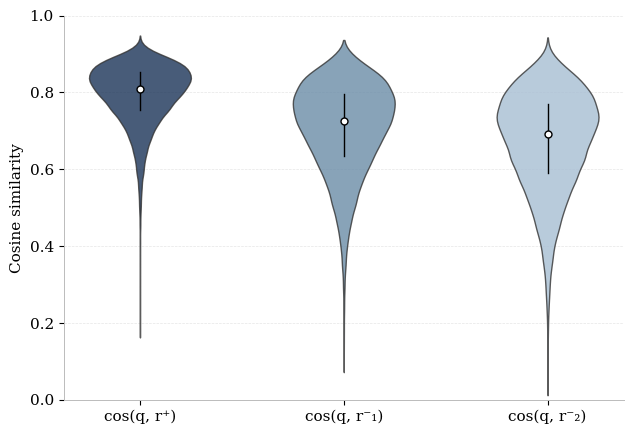

In [7]:
plt.rcParams.update({
    'font.family': 'serif',
    'font.serif': ['DejaVu Serif', 'serif'],
    'font.size': 12,
    'axes.labelsize': 11,
    'axes.titlesize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'axes.edgecolor': '#bbbbbb',
    'axes.linewidth': 0.7,
})

COLOR_DARK_BLUE  = '#1A3357'
COLOR_GREY_BLUE  = '#6A8CA7'
COLOR_LIGHT_BLUE = '#a7bed3'

fig, ax = plt.subplots(figsize=(6.5, 4.5))

data = [sim_q_pos, sim_q_neg1, sim_q_neg2]

vp = ax.violinplot(data, showmeans=False, showmedians=False, showextrema=False)

colors = [COLOR_DARK_BLUE, COLOR_GREY_BLUE, COLOR_LIGHT_BLUE]
for body, c in zip(vp['bodies'], colors):
    body.set_facecolor(c)
    body.set_edgecolor('#333333')
    body.set_alpha(0.8)

quartiles = [np.percentile(d, [25, 50, 75]) for d in data]
positions = np.arange(1, len(data) + 1)

for (q1, q2, q3), x in zip(quartiles, positions):
    ax.plot([x, x], [q1, q3], color='black', linewidth=1.0)
    ax.scatter(x, q2, color='white', edgecolor='black', zorder=3, s=25)

ax.set_xticks(positions)
ax.set_xticklabels(['cos(q, r⁺)', 'cos(q, r⁻₁)', 'cos(q, r⁻₂)'])
ax.set_ylabel('Cosine similarity')
ax.set_ylim(0.0, 1.0)

ax.set_axisbelow(True)
ax.yaxis.grid(True, linestyle='--', linewidth=0.5, color='#cccccc', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("fig_cosine_similarity_distributions.pdf", format="pdf", bbox_inches="tight")
plt.savefig("fig_cosine_similarity_distributions.png", dpi=600, bbox_inches="tight")
plt.show()